# Lab-4: Implementation of CNN from scratch
## Reg.No: 2548514
### 4.1  Implementation of CNN from scratch on your choice of dataset.

In [ ]:
# Cell 1: Load Rock-Paper-Scissors
import tensorflow_datasets as tfds
import numpy as np

ds_train, ds_test = tfds.load('rock_paper_scissors', split=['train', 'test'], as_supervised=True)

IMG_SIZE = 32
MAX_SAMPLES = 600

def process(ds, max_samples):
    X, y = [], []
    for img, label in ds.take(max_samples):
        img_resized = np.array(img) / 255.0  # Already (300,300,3)
        from PIL import Image
        img_pil = Image.fromarray((img_resized * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE))
        X.append(np.array(img_pil) / 255.0)
        y.append(int(label))
    return np.array(X, dtype=np.float32), np.array(y)

X_train, y_train = process(ds_train, MAX_SAMPLES)
X_test, y_test = process(ds_test, 200)

classes = ['rock', 'paper', 'scissors']
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.JZ1QYW_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.JZ1QYW_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.
Train: (600, 32, 32, 3), Test: (200, 32, 32, 3)


In [ ]:
import numpy as np
import gc

# HELPER FUNCTIONS

def one_hot(y, num_classes=3):
    out = np.zeros((len(y), num_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1
    return out

def softmax(X):
    X_shifted = X - np.max(X, axis=1, keepdims=True)
    ex = np.exp(X_shifted)
    return ex / np.sum(ex, axis=1, keepdims=True)

def cross_entropy_loss(probs, y_oh):
    N = len(probs)
    loss = -np.sum(y_oh * np.log(probs + 1e-9)) / N
    dout = (probs - y_oh) / N
    return loss, dout

# CONV LAYER

class ConvLayer:
    def __init__(self, in_channels, num_filters, kernel_size=3, padding=1, lr=0.001):
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.padding = padding
        self.lr = lr
        scale = np.sqrt(2.0 / (in_channels * kernel_size * kernel_size))
        self.filters = np.random.randn(num_filters, in_channels, kernel_size, kernel_size).astype(np.float32) * scale
        self.biases  = np.zeros((num_filters, 1), dtype=np.float32)
        # Adam states
        self.mW = np.zeros_like(self.filters); self.vW = np.zeros_like(self.filters)
        self.mb = np.zeros_like(self.biases);  self.vb = np.zeros_like(self.biases)
        self.t = 0

    def _pad(self, X):
        if self.padding > 0:
            return np.pad(X, ((0,0),(0,0),(self.padding,self.padding),(self.padding,self.padding)), mode='constant')
        return X

    def forward(self, X):
        # X: (N, C, H, W)
        self.X_orig = X
        N, C, H, W = X.shape
        k, p = self.kernel_size, self.padding
        H_out = H - k + 2*p + 1
        W_out = W - k + 2*p + 1
        Xp = self._pad(X)
        self.Xp = Xp
        out = np.zeros((N, self.num_filters, H_out, W_out), dtype=np.float32)
        for f in range(self.num_filters):
            for i in range(H_out):
                for j in range(W_out):
                    patch = Xp[:, :, i:i+k, j:j+k]
                    out[:, f, i, j] = np.sum(patch * self.filters[f], axis=(1,2,3)) + self.biases[f]
        return out

    def backward(self, dout):
        k, p = self.kernel_size, self.padding
        H_out, W_out = dout.shape[2], dout.shape[3]
        dXp = np.zeros_like(self.Xp)
        dW  = np.zeros_like(self.filters)
        db  = np.zeros_like(self.biases)
        for f in range(self.num_filters):
            for i in range(H_out):
                for j in range(W_out):
                    patch      = self.Xp[:, :, i:i+k, j:j+k]
                    dout_ij    = dout[:, f, i, j]
                    dW[f]     += np.sum(patch * dout_ij[:, None, None, None], axis=0)
                    db[f]     += np.sum(dout_ij)
                    dXp[:, :, i:i+k, j:j+k] += self.filters[f] * dout_ij[:, None, None, None]
        # Adam update
        self.t += 1
        b1, b2, eps = 0.9, 0.999, 1e-8
        self.mW = b1*self.mW + (1-b1)*dW
        self.vW = b2*self.vW + (1-b2)*dW**2
        self.filters -= self.lr * (self.mW/(1-b1**self.t)) / (np.sqrt(self.vW/(1-b2**self.t)) + eps)
        self.mb = b1*self.mb + (1-b1)*db
        self.vb = b2*self.vb + (1-b2)*db**2
        self.biases -= self.lr * (self.mb/(1-b1**self.t)) / (np.sqrt(self.vb/(1-b2**self.t)) + eps)
        return dXp[:, :, p:-p, p:-p] if p > 0 else dXp

# ============================================================
# RELU
# ============================================================

class ReLU:
    def forward(self, X):
        self.mask = (X > 0)
        return X * self.mask
    def backward(self, dout):
        return dout * self.mask

# ============================================================
# MAX POOLING
# ============================================================

class MaxPool2D:
    def __init__(self, pool_size=2):
        self.pool_size = pool_size

    def forward(self, X):
        self.X = X
        N, C, H, W = X.shape
        p = self.pool_size
        H_out, W_out = H // p, W // p
        out = np.zeros((N, C, H_out, W_out), dtype=np.float32)
        for i in range(H_out):
            for j in range(W_out):
                out[:, :, i, j] = np.max(X[:, :, i*p:(i+1)*p, j*p:(j+1)*p], axis=(2,3))
        return out

    def backward(self, dout):
        N, C, H, W = self.X.shape
        p = self.pool_size
        H_out, W_out = H // p, W // p
        dX = np.zeros_like(self.X)
        for i in range(H_out):
            for j in range(W_out):
                patch    = self.X[:, :, i*p:(i+1)*p, j*p:(j+1)*p]
                max_val  = np.max(patch, axis=(2,3), keepdims=True)
                mask     = (patch == max_val)
                dX[:, :, i*p:(i+1)*p, j*p:(j+1)*p] += mask * dout[:, :, i, j][:, :, None, None]
        return dX

# ============================================================
# FLATTEN
# ============================================================

class Flatten:
    def forward(self, X):
        self.shape = X.shape
        return X.reshape(X.shape[0], -1)
    def backward(self, dout):
        return dout.reshape(self.shape)

# ============================================================
# DENSE LAYER
# ============================================================

class DenseLayer:
    def __init__(self, in_features, out_features, lr=0.001):
        scale    = np.sqrt(2.0 / in_features)
        self.W   = np.random.randn(in_features, out_features).astype(np.float32) * scale
        self.b   = np.zeros((1, out_features), dtype=np.float32)
        self.lr  = lr
        self.mW  = np.zeros_like(self.W); self.vW = np.zeros_like(self.W)
        self.mb  = np.zeros_like(self.b); self.vb = np.zeros_like(self.b)
        self.t   = 0

    def forward(self, X):
        self.X = X
        return X @ self.W + self.b

    def backward(self, dout):
        dX = dout @ self.W.T
        dW = self.X.T @ dout
        db = np.sum(dout, axis=0, keepdims=True)
        self.t += 1
        b1, b2, eps = 0.9, 0.999, 1e-8
        self.mW = b1*self.mW + (1-b1)*dW
        self.vW = b2*self.vW + (1-b2)*dW**2
        self.W -= self.lr * (self.mW/(1-b1**self.t)) / (np.sqrt(self.vW/(1-b2**self.t)) + eps)
        self.mb = b1*self.mb + (1-b1)*db
        self.vb = b2*self.vb + (1-b2)*db**2
        self.b -= self.lr * (self.mb/(1-b1**self.t)) / (np.sqrt(self.vb/(1-b2**self.t)) + eps)
        return dX

# ============================================================
# DROPOUT
# ============================================================

class Dropout:
    def __init__(self, rate=0.4):
        self.rate     = rate
        self.training = True

    def forward(self, X):
        if self.training:
            self.mask = (np.random.rand(*X.shape) > self.rate).astype(np.float32) / (1 - self.rate)
            return X * self.mask
        return X

    def backward(self, dout):
        return dout * self.mask if self.training else dout

print("✅ All layers defined successfully!")

✅ All layers defined successfully!


In [ ]:
# ============================================================
# CNN MODEL
# Architecture:
#   Input (32x32x3)
#   → Conv(3→8, 3x3, pad=1) → ReLU → MaxPool(2x2)  → (8, 16, 16)
#   → Conv(8→16, 3x3, pad=1) → ReLU → MaxPool(2x2) → (16, 8, 8)
#   → Flatten → (1024)
#   → Dense(1024→64) → ReLU → Dropout(0.4)
#   → Dense(64→3) → Softmax
# ============================================================

class SimpleCNN:
    def __init__(self, lr=0.001):
        self.conv1    = ConvLayer(in_channels=3,  num_filters=8,  kernel_size=3, padding=1, lr=lr)
        self.relu1    = ReLU()
        self.pool1    = MaxPool2D(pool_size=2)

        self.conv2    = ConvLayer(in_channels=8,  num_filters=16, kernel_size=3, padding=1, lr=lr)
        self.relu2    = ReLU()
        self.pool2    = MaxPool2D(pool_size=2)

        self.flatten  = Flatten()
        self.fc1      = DenseLayer(16*8*8, 64, lr=lr)
        self.relu3    = ReLU()
        self.dropout  = Dropout(rate=0.4)
        self.fc2      = DenseLayer(64, 3, lr=lr)

        self.layers   = [
            self.conv1, self.relu1, self.pool1,
            self.conv2, self.relu2, self.pool2,
            self.flatten,
            self.fc1, self.relu3, self.dropout,
            self.fc2
        ]

    def forward(self, X, training=True):
        # X comes in as (N, H, W, C) — convert to (N, C, H, W) for conv
        self.dropout.training = training
        out = X.transpose(0, 3, 1, 2)
        for layer in self.layers:
            out = layer.forward(out)
        return out   # logits: (N, 3)

    def backward(self, dout):
        for layer in reversed(self.layers):
            dout = layer.backward(dout)

    def predict(self, X, batch_size=32):
        preds = []
        for i in range(0, len(X), batch_size):
            logits = self.forward(X[i:i+batch_size], training=False)
            preds.extend(np.argmax(softmax(logits), axis=1))
        return np.array(preds)

    def accuracy(self, X, y, batch_size=32):
        preds = self.predict(X, batch_size)
        return np.mean(preds == y)

print("✅ CNN model class ready!")
print("\nArchitecture Summary:")
print("  Input        : (N, 32, 32, 3)")
print("  Conv1 + ReLU : (N, 8,  32, 32)")
print("  MaxPool1     : (N, 8,  16, 16)")
print("  Conv2 + ReLU : (N, 16, 16, 16)")
print("  MaxPool2     : (N, 16, 8,  8 )")
print("  Flatten      : (N, 1024)")
print("  Dense1+ReLU  : (N, 64)")
print("  Dropout(0.4) : (N, 64)")
print("  Dense2       : (N, 3)  ← logits")
print("  Softmax      : (N, 3)  ← probabilities")

✅ CNN model class ready!

Architecture Summary:
  Input        : (N, 32, 32, 3)
  Conv1 + ReLU : (N, 8,  32, 32)
  MaxPool1     : (N, 8,  16, 16)
  Conv2 + ReLU : (N, 16, 16, 16)
  MaxPool2     : (N, 16, 8,  8 )
  Flatten      : (N, 1024)
  Dense1+ReLU  : (N, 64)
  Dropout(0.4) : (N, 64)
  Dense2       : (N, 3)  ← logits
  Softmax      : (N, 3)  ← probabilities


In [ ]:
import time

def train(model, X_train, y_train, X_val, y_val,
          epochs=15, batch_size=16):

    N      = len(X_train)
    y_oh   = one_hot(y_train, num_classes=3)
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"Training on {N} samples | Batch size: {batch_size} | Epochs: {epochs}\n")
    print(f"{'Epoch':<8} {'Loss':<12} {'Train Acc':<14} {'Val Acc':<12} {'Time'}")
    print("-" * 58)

    for epoch in range(epochs):
        start = time.time()

        # Shuffle training data each epoch
        idx    = np.random.permutation(N)
        X_s    = X_train[idx]
        y_oh_s = y_oh[idx]
        y_s    = y_train[idx]

        epoch_loss  = 0.0
        num_batches = 0

        for i in range(0, N, batch_size):
            Xb    = X_s[i:i+batch_size]
            yb_oh = y_oh_s[i:i+batch_size]

            # Forward pass
            logits = model.forward(Xb, training=True)
            probs  = softmax(logits)

            # Compute loss + gradient
            loss, dout = cross_entropy_loss(probs, yb_oh)

            # Backward pass
            model.backward(dout)

            epoch_loss  += loss
            num_batches += 1

            # Cleanup to avoid memory buildup
            del Xb, logits, probs, dout
            gc.collect()

        avg_loss = epoch_loss / num_batches

        # Accuracy on random subset (faster than full dataset)
        eval_idx  = np.random.choice(N, min(150, N), replace=False)
        train_acc = model.accuracy(X_train[eval_idx], y_train[eval_idx])
        val_acc   = model.accuracy(X_val, y_val)

        elapsed = time.time() - start
        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"{epoch+1:<8} {avg_loss:<12.4f} {train_acc*100:<14.2f} {val_acc*100:<12.2f} {elapsed:.1f}s")
        gc.collect()

    print("\n✅ Training complete!")
    return history

print("✅ Training function ready!")

✅ Training function ready!


In [ ]:
# INITIALIZE & TRAIN

print(f"Train set : {X_train.shape}  Labels: {y_train.shape}")
print(f"Test set  : {X_test.shape}   Labels: {y_test.shape}")
print(f"Classes   : {classes}\n")

# Build model
model = SimpleCNN(lr=0.001)

# Train
history = train(
    model,
    X_train, y_train,
    X_test,  y_test,
    epochs=15,
    batch_size=16
)

Train set : (600, 32, 32, 3)  Labels: (600,)
Test set  : (200, 32, 32, 3)   Labels: (200,)
Classes   : ['rock', 'paper', 'scissors']

Training on 600 samples | Batch size: 16 | Epochs: 15

Epoch    Loss         Train Acc      Val Acc      Time
----------------------------------------------------------
1        1.1329       69.33          41.50        33.7s
2        0.9288       90.00          61.00        32.4s
3        0.6474       88.67          67.00        33.7s
4        0.4666       96.00          79.00        33.0s
5        0.3182       98.67          77.50        33.5s
6        0.2549       98.00          84.00        33.0s
7        0.2097       98.67          67.00        33.7s
8        0.1507       98.67          75.50        34.0s
9        0.1343       98.67          70.50        33.5s
10       0.1448       100.00         68.00        33.5s
11       0.1133       96.00          59.00        33.8s
12       0.0871       99.33          69.50        33.4s
13       0.0790       98.

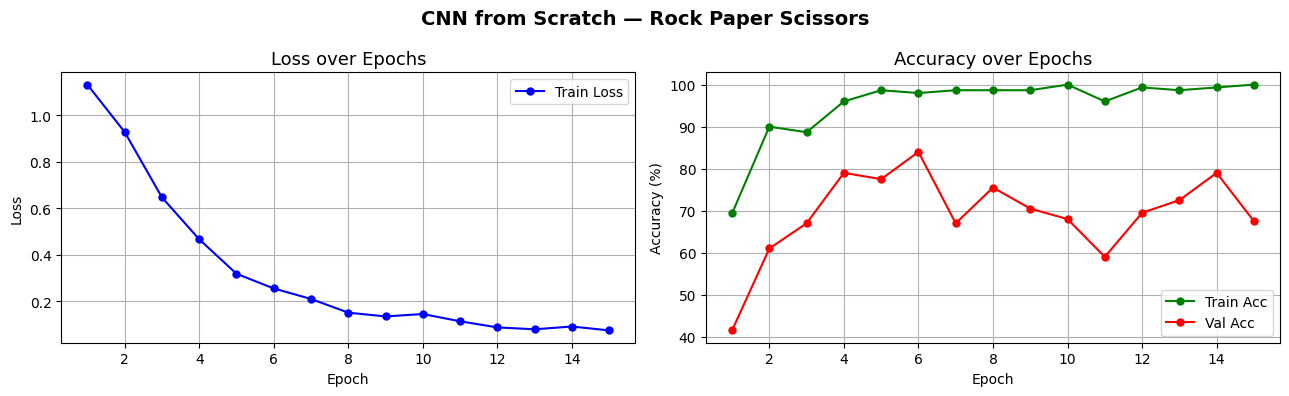

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Loss plot
    axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=5, label='Train Loss')
    axes[0].set_title('Loss over Epochs', fontsize=13)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True)

    # Accuracy plot
    axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'g-o', markersize=5, label='Train Acc')
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', markersize=5, label='Val Acc')
    axes[1].set_title('Accuracy over Epochs', fontsize=13)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(True)

    plt.suptitle('CNN from Scratch — Rock Paper Scissors', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history)

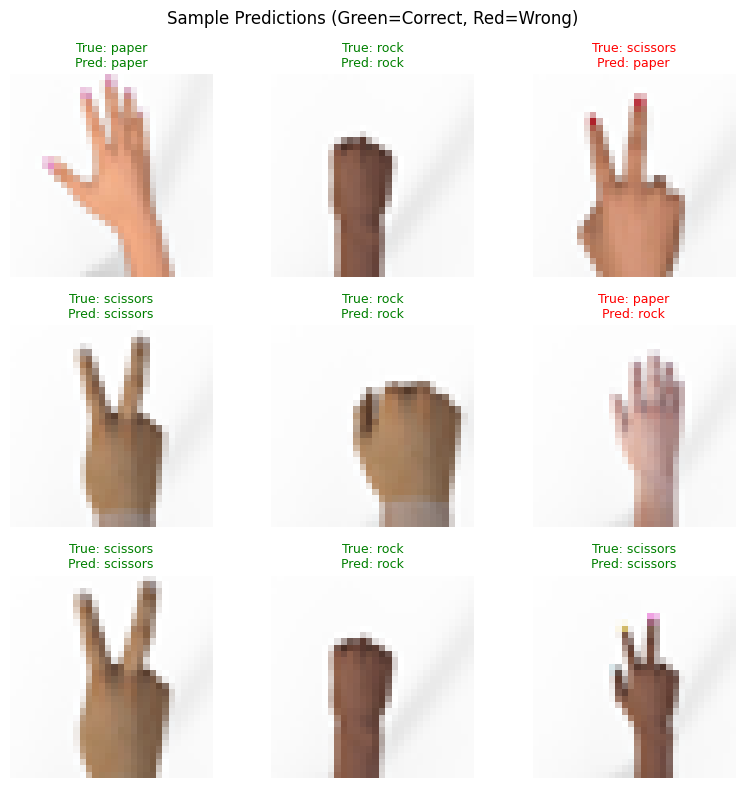

In [ ]:
def show_predictions(model, X, y, classes, n=9):
    idx   = np.random.choice(len(X), n, replace=False)
    preds = model.predict(X[idx])

    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    fig.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=12)

    for k, ax in enumerate(axes.flat):
        ax.imshow(X[idx[k]])
        true_lbl = classes[y[idx[k]]]
        pred_lbl = classes[preds[k]]
        color    = 'green' if preds[k] == y[idx[k]] else 'red'
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color=color, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(model, X_test, y_test, classes)

In [ ]:
from collections import Counter

# Final accuracy
final_acc = model.accuracy(X_test, y_test)
preds_all = model.predict(X_test)

# Per-class accuracy
print("=" * 40)
print(f"   FINAL TEST ACCURACY: {final_acc*100:.2f}%")
print("=" * 40)
print("\nPer-class breakdown:")
for i, cls in enumerate(classes):
    cls_idx  = np.where(y_test == i)[0]
    cls_acc  = np.mean(preds_all[cls_idx] == i)
    print(f"  {cls:<12}: {cls_acc*100:.2f}%  ({len(cls_idx)} samples)")

print("\nPrediction distribution:")
pred_counts = Counter(preds_all)
for i, cls in enumerate(classes):
    print(f"  {cls:<12}: {pred_counts[i]} predicted")

   FINAL TEST ACCURACY: 67.50%

Per-class breakdown:
  rock        : 71.21%  (66 samples)
  paper       : 62.69%  (67 samples)
  scissors    : 68.66%  (67 samples)

Prediction distribution:
  rock        : 86 predicted
  paper       : 62 predicted
  scissors    : 52 predicted


In [ ]:

print("""`
HOW ENSEMBLE IMPROVES PREDICTIONS:
  WBF (Weighted Boxes Fusion) fuses boxes from both models:
  • Boxes agreed upon by both → higher confidence score
  • Boxes seen by only one model → still retained if conf > threshold
  • Duplicate/overlapping boxes → merged into one clean detection
  • Result: fewer false negatives, fewer duplicate detections

  Compared to single models:
  Better recall  (catches objects missed by one model)
  Better precision (fuses redundant detections)
  More robust to model-specific failures
""")


HOW ENSEMBLE IMPROVES PREDICTIONS:
  WBF (Weighted Boxes Fusion) fuses boxes from both models:
  • Boxes agreed upon by both → higher confidence score
  • Boxes seen by only one model → still retained if conf > threshold
  • Duplicate/overlapping boxes → merged into one clean detection
  • Result: fewer false negatives, fewer duplicate detections

  Compared to single models:
  Better recall  (catches objects missed by one model)
  Better precision (fuses redundant detections)
  More robust to model-specific failures

